# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## Load dataset

In [3]:
df = pd.read_csv("Message_Intelligence.csv")

df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


## About DataSet

In [4]:
print("Shape :", df.shape)

Shape : (5200, 16)


In [5]:
df.columns

Index(['message_id', 'message_text', 'message_length', 'word_count',
       'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score',
       'legit_keyword_score', 'sender_activity_score',
       'sender_account_age_days', 'messages_sent_last_24h', 'timestamp',
       'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   str    
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   str    
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week              5200 non-n

In [7]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


## Check null value

In [8]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

## Numerical Column

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['message_id', 'message_length', 'word_count', 'num_urls', 'num_digits',
       'num_special_chars', 'spam_keyword_score', 'legit_keyword_score',
       'sender_activity_score', 'sender_account_age_days',
       'messages_sent_last_24h', 'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='str')

## Fill Null Value

In [10]:
num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

## Categorical Column

In [11]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

C:\Users\Shyamdev verma\AppData\Local\Temp\ipykernel_6148\910776789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Index(['message_text', 'timestamp'], dtype='str')

In [13]:
df.isnull().sum()

message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64

## Histogram plot

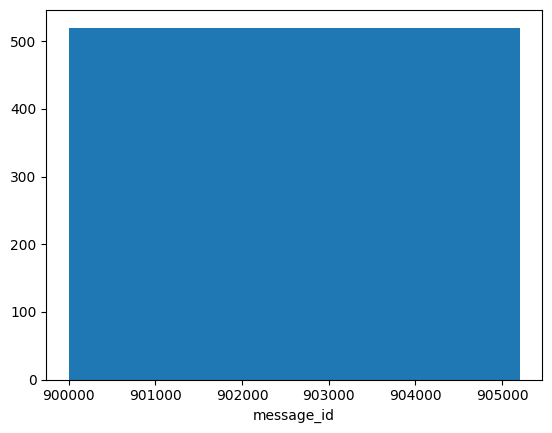

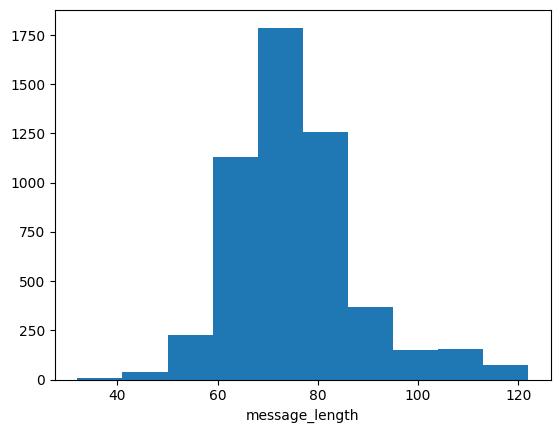

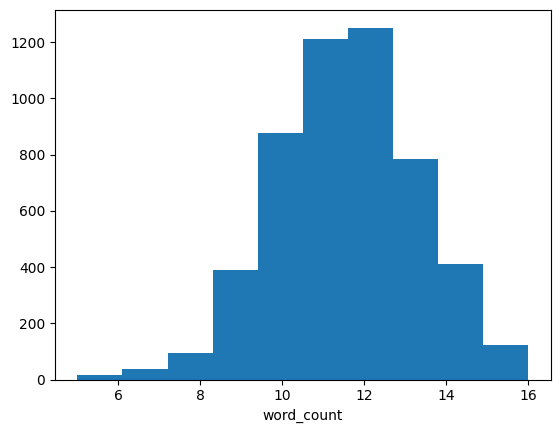

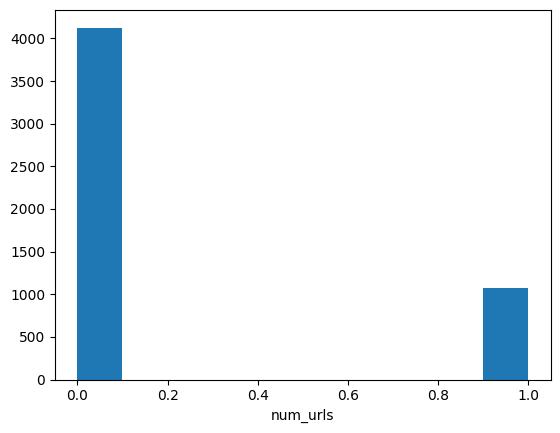

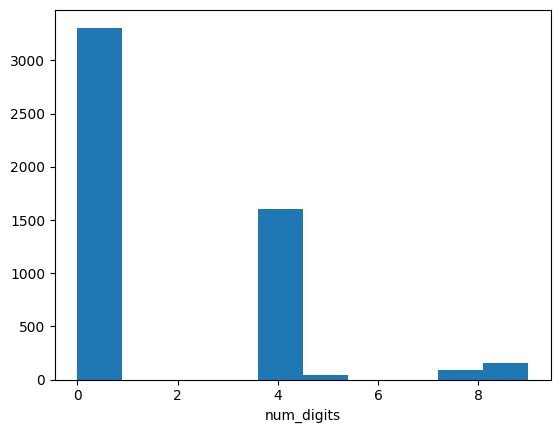

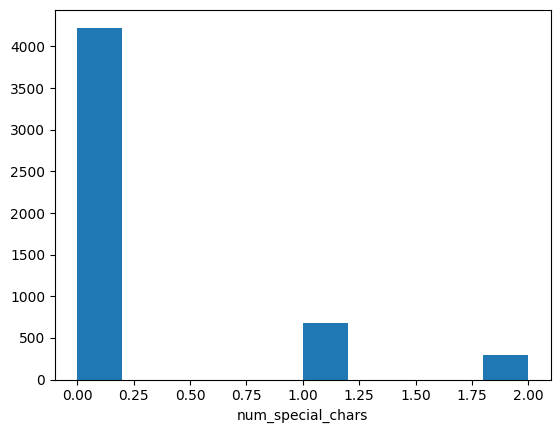

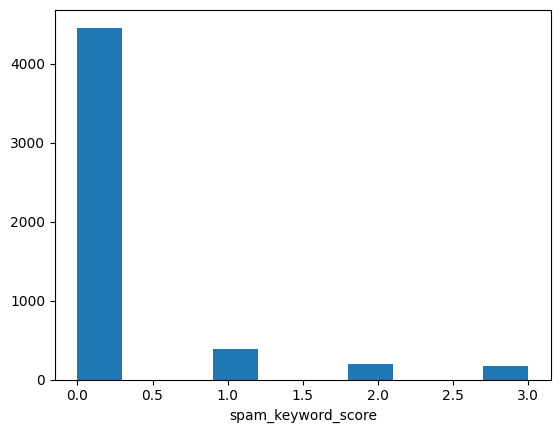

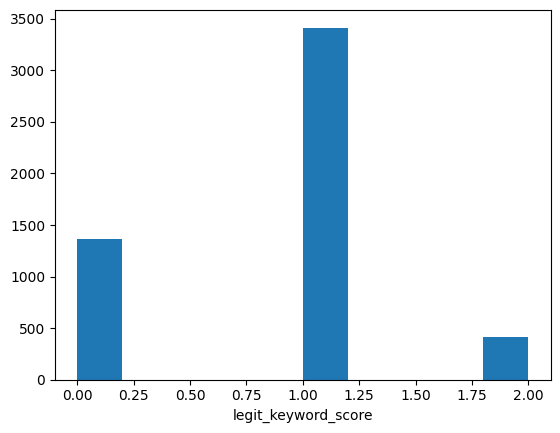

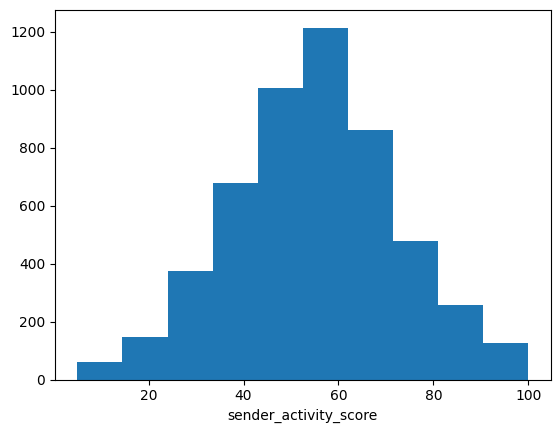

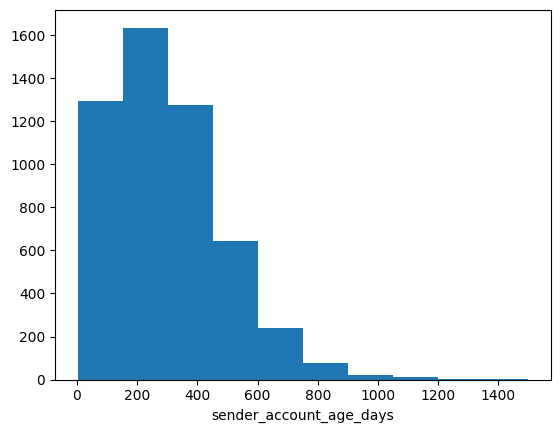

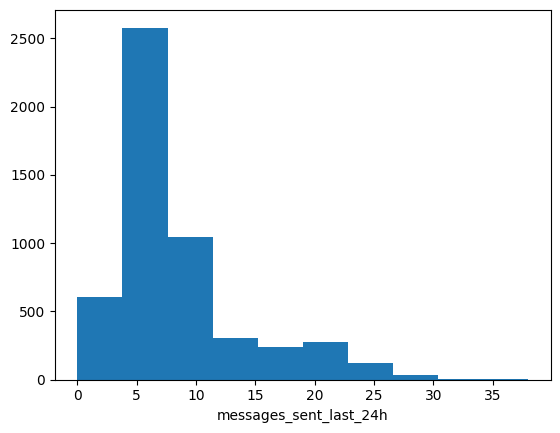

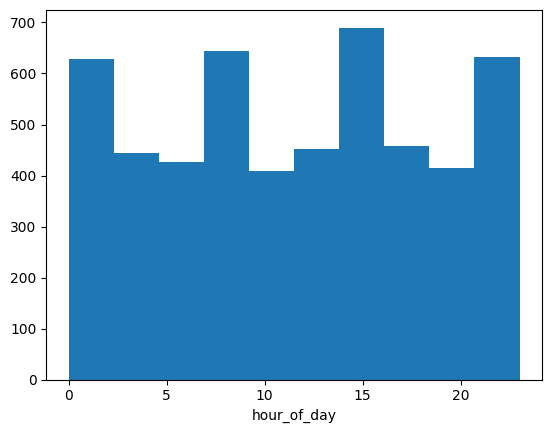

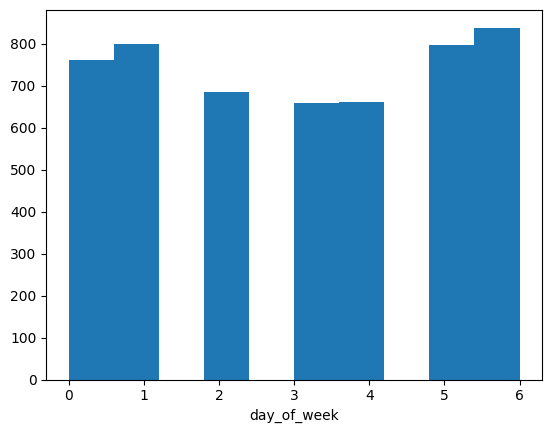

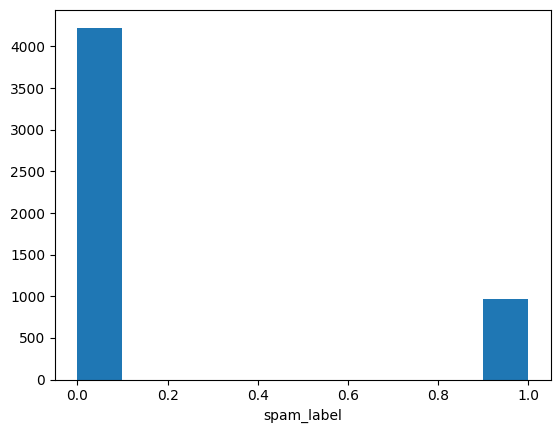

In [14]:
for cols in num_cols:
    plt.hist(df[cols])
    plt.xlabel(cols)
    plt.show()

In [15]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001.0,Please find the attached invoice for the updat...,99.0,11.0,1.0,4.0,0.0,0.0,1.0,56.6,500.0,6.0,2025-11-24 02:00:00,2.0,0.0,0.0
1,900002.0,Let's catch up tomorrow regarding the timeline...,73.0,12.0,0.0,0.0,0.0,0.0,0.0,16.6,207.0,0.0,2025-12-17 21:00:00,21.0,2.0,0.0
2,900003.0,Can you send the report by end of day? next Mo...,67.0,13.0,0.0,0.0,0.0,0.0,1.0,25.7,418.0,6.0,2025-11-15 13:00:00,13.0,5.0,0.0
3,900004.0,Can you send the report by end of day? 10:30 A...,64.0,13.0,0.0,4.0,0.0,0.0,1.0,48.8,276.0,5.0,2025-12-17 23:00:00,23.0,2.0,0.0
4,900005.0,Could you review the document and share feedba...,84.0,14.0,0.0,0.0,0.0,0.0,1.0,33.0,683.0,7.0,2025-11-29 11:00:00,11.0,5.0,0.0


## Feature Remove

In [16]:
df.drop(['message_id','message_text','timestamp'],axis=1,inplace=True)

In [17]:
df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,99.0,11.0,1.0,4.0,0.0,0.0,1.0,56.6,500.0,6.0,2.0,0.0,0.0
1,73.0,12.0,0.0,0.0,0.0,0.0,0.0,16.6,207.0,0.0,21.0,2.0,0.0
2,67.0,13.0,0.0,0.0,0.0,0.0,1.0,25.7,418.0,6.0,13.0,5.0,0.0
3,64.0,13.0,0.0,4.0,0.0,0.0,1.0,48.8,276.0,5.0,23.0,2.0,0.0
4,84.0,14.0,0.0,0.0,0.0,0.0,1.0,33.0,683.0,7.0,11.0,5.0,0.0


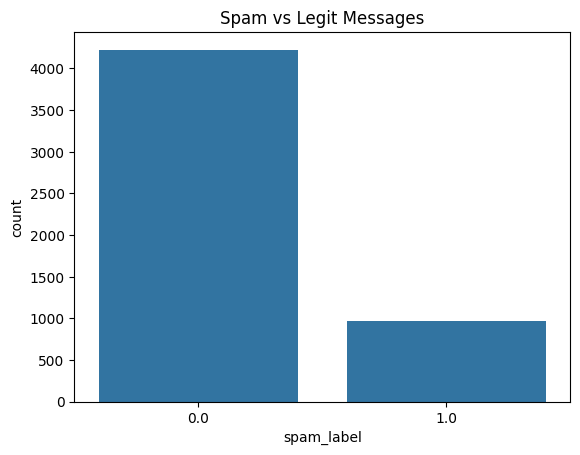

In [18]:
sns.countplot(x='spam_label', data=df)

plt.title("Spam vs Legit Messages")
plt.show()

## Correlation Visualization

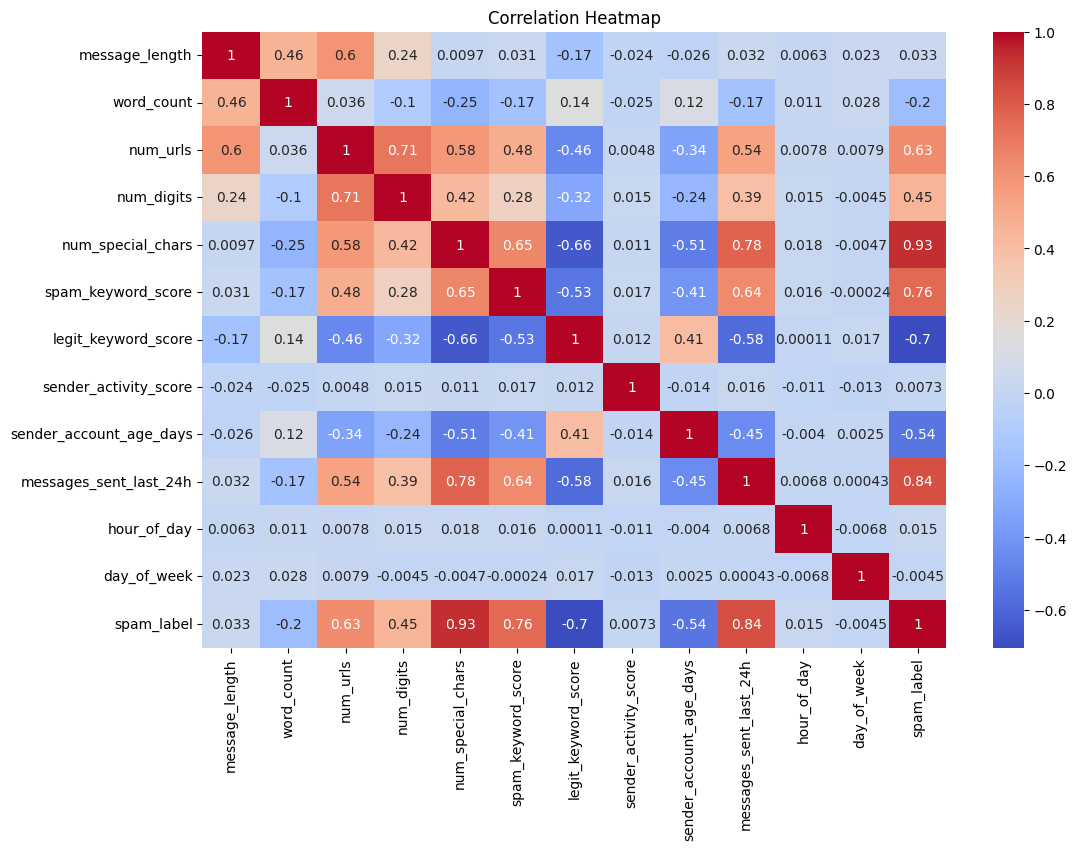

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Scaling Dataset

In [20]:
scaling_column = ['message_length',
 'word_count',
 'num_urls',
 'num_digits',
 'num_special_chars',
 'spam_keyword_score',
 'legit_keyword_score',
 'sender_activity_score',
 'sender_account_age_days',
 'messages_sent_last_24h'
 ]

In [21]:
scaler = StandardScaler()

In [22]:
df[scaling_column] = scaler.fit_transform(df[scaling_column])

print("Scaling Completed")

Scaling Completed


In [23]:
df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,1.924176,-0.284236,1.960029,0.959861,-0.446817,-0.364023,0.327518,0.100738,1.074541,-0.410937,2.0,0.0,0.0
1,-0.163476,0.337306,-0.510197,-0.696033,-0.446817,-0.364023,-1.468996,-2.183030,-0.470316,-1.501272,21.0,2.0,0.0
2,-0.645242,0.958849,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.663473,0.642191,-0.410937,13.0,5.0,0.0
3,-0.886125,0.958849,-0.510197,0.959861,-0.446817,-0.364023,0.327518,-0.344596,-0.106511,-0.592660,23.0,2.0,0.0
4,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.246685,2.039417,-0.229215,11.0,5.0,0.0


## Save Dataset

In [24]:
df.to_csv('clean_data.csv',index=False)

## conclusion
The Message Intelligence Dataset was successfully preprocessed through a complete data cleaning and transformation pipeline. Missing values were handled using median imputation, irrelevant columns were removed, numerical features were standardized, and correlations among features were analyzed.

The final dataset is clean, normalized, and ready for machine learning classification models such as Support Vector Classifier (SVC), K-Nearest Neighbors (KNN), Gaussian Naive Bayes, Logistic Regression, Decision Tree Classifier, and Random Forest Classifier